In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv("EV_Data (1).csv")

df = df.dropna()

df['state'] = LabelEncoder().fit_transform(df['state'])

df['Party'] = LabelEncoder().fit_transform(df['Party'])

df = df.rename(columns={"DC Fast": "DC_Fast"})

In [ ]:
X = df[['gasoline_price_per_gallon', 'personal', 'devharm', 'exp', 'fuel_economy', 'DC_Fast', 'Per_Capita_Income']]
y = df['EV Share (%)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))  # regression output

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.2613 - val_loss: 0.1295
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1863 - val_loss: 0.1106
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1373 - val_loss: 0.0964
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1101 - val_loss: 0.0794
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0946 - val_loss: 0.0670
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0825 - val_loss: 0.0586
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0721 - val_loss: 0.0542
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0663 - val_loss: 0.0543
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0609 - val_loss: 0.0486
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0572 - val_loss: 0.0485
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0539 - val_loss: 0.0462
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

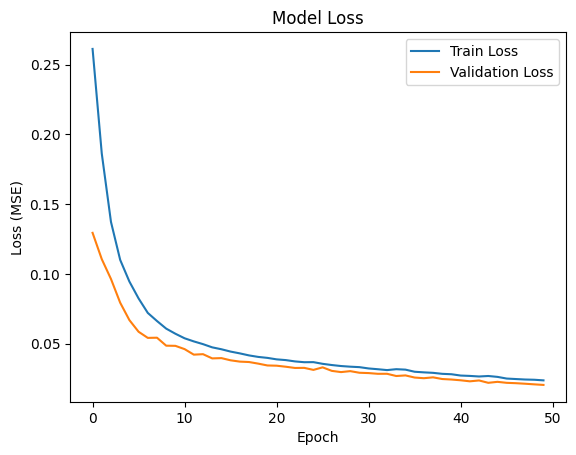

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

print("R^2:", r2_score(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
R^2: 0.8726695650957332


In [ ]:
#model.save("FINAL_ev_model1.keras")